### Phase 1

In [1]:
%matplotlib ipympl

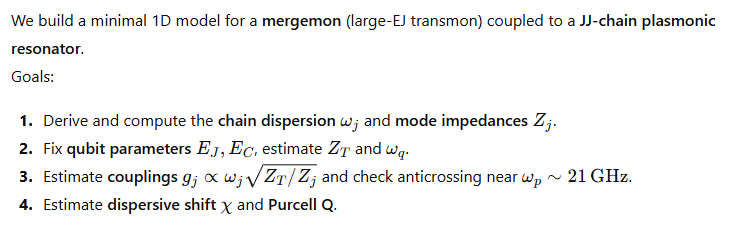

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

h = 6.62607015e-34          # Planck [J*s]
hbar = h / (2*np.pi)
e = 1.602176634e-19         # [C]
Phi0 = h/(2*e)              # [Wb]
RQ = h/(2*e)**2             #  ~ 6.45 kΩ
GHz = 1e9*2*np.pi           # [rad/s] per GHz


### LC couplings

parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=66314.6 Ohm, C2=0.00 pF, L2=1759.05 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=10589.0 Ohm, C2=0.00 pF, L2=280.88 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=4134.3 Ohm, C2=0.01 pF, L2=109.66 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=2186.2 Ohm, C2=0.01 pF, L2=57.99 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=1349.5 Ohm, C2=0.02 pF, L2=35.80 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=915.1 Ohm, C2=0.03 pF, L2=24.27 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=661.2 Ohm, C2=0.04 pF, L2=17.54 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=499.9 Ohm, C2=0.05 pF, L2=13.26 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=391.2 Ohm, C2=0.07 pF, L2=10.38 nH
parallel LC: Z1=26.5 Ohm, C1=1.00 pF, L1=0.70 nH
sequential LC: Z2=314.

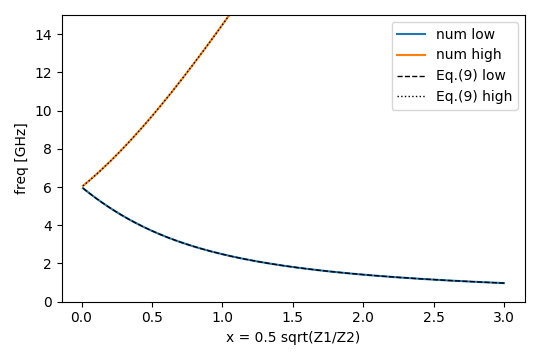

In [2]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

def coupled_LC_modes(C1, L1, C2, L2):
    # capacitance matrix
    C = np.array([[C1, 0],
                  [0,  C2]])

    # inverse inductance matrix from Eq.(2)
    Linv = np.array([[1/L1 + 1/L2,   -1/L2      ],
                     [    -1/L2,       1/L2     ]])

    # equation of motion:
    #  C φ¨ + L^{-1} φ = 0  →  det( -ω^2 C + L^{-1} ) = 0
    M = la.inv(C) @ Linv

    w2, _ = la.eig(M)
    w = np.sqrt(np.real(w2))
    w = np.sort(w)
    return w

import numpy as np

omega0 = 2*np.pi*6e9
C1 = 1e-12
L1 = 1/((omega0)**2 * C1)       # choose C=1pF → set L
Z1 = np.sqrt(L1/C1)

xs = np.linspace(0.01,3,200)
ws1, ws2 = [], []

for x in xs:
    Z2 = Z1/(4*x**2)               # from definition of x
    C2 = 1/(omega0*Z2)
    L2 = Z2**2 * C2
    print('parallel LC: Z1={:.1f} Ohm, C1={:.2f} pF, L1={:.2f} nH'.format(Z1, C1*1e12, L1*1e9))
    print('sequential LC: Z2={:.1f} Ohm, C2={:.2f} pF, L2={:.2f} nH'.format(Z2, C2*1e12, L2*1e9))
    w = coupled_LC_modes(C1, L1, C2, L2)
    ws1.append(w[0])
    ws2.append(w[1])


# Analytic prediction 
w1_an = omega0*(np.sqrt(1+np.array(xs)**2)-np.array(xs)) 
w2_an = omega0*(np.sqrt(1+np.array(xs)**2)+np.array(xs)) 
plt.figure(figsize=(5.4,3.6)) 
plt.plot(xs, np.array(ws1)/(2*np.pi*1e9), 'C0', label='num low')
plt.plot(xs, np.array(ws2)/(2*np.pi*1e9), 'C1', label='num high') 
plt.plot(xs, w1_an/(2*np.pi*1e9), 'k--', lw=1, label='Eq.(9) low') 
plt.plot(xs, w2_an/(2*np.pi*1e9), 'k:', lw=1, label='Eq.(9) high')
plt.xlabel('x = 0.5 sqrt(Z1/Z2)'); 
plt.ylabel('freq [GHz]'); 
plt.ylim(0,15)

plt.legend(); plt.tight_layout(); plt.show()


### Chain - numerical

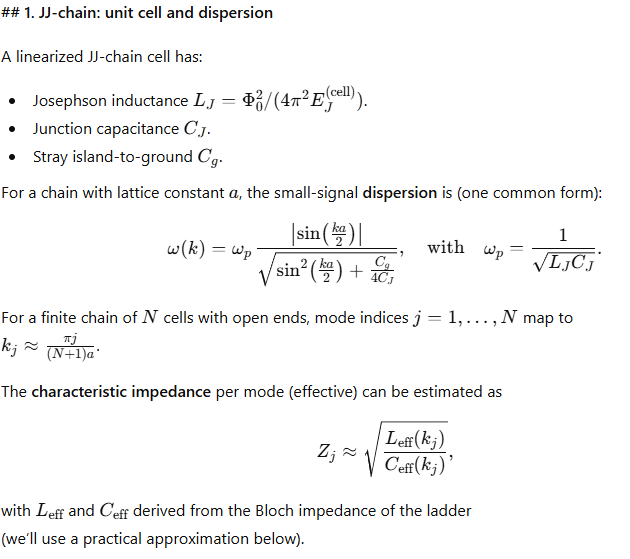

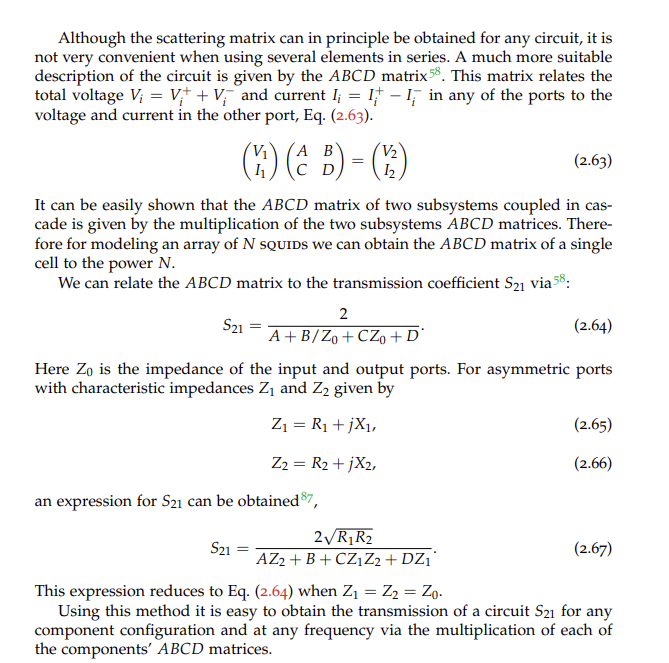

In [ ]:
# file:///C:/Users/gusarov/Downloads/Javier_Puertas_thesis_compressed.pdf

In [ ]:
# TODO
# Generate the spectrum as a function of flux
# Make the 1st mode at 20 GHz
# Consider transmon in the middle and in the end
# plot eigenfunctions (eigenvectors) - both
# impedance calculation - to check (both)
# Target impedance 6 kOhm\
# Cs modifies the lowest mode a lot sweep from 0.1 fF to 10 fF
# Qubit (or harm oscillator) from 40 GHz to 5 GHz (plot eigenmodes as a function of flux) - for LJ use transmon flux dependence
# Add parasitic inductance to LJ (between junction and junction) - 2nd order effect

JJ chain parameters:
EJ = 209.2 GHz, EC = 0.36 GHz
LJ = 0.78 nH, CJ = 54.00 fF, Cg = 0.02 fF
Plasma freq: wp/2pi = 24.5000 GHz


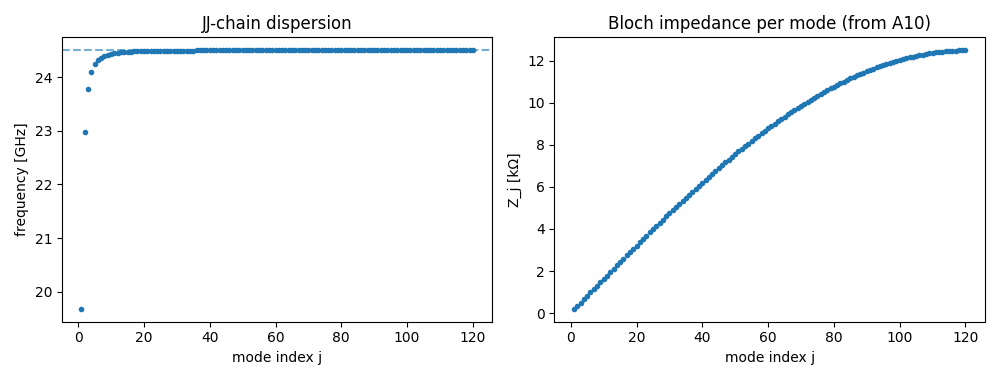

In [25]:
import numpy as np
import scipy.constants as const

# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 24.5
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.6                       # Width in um (200 nm)
L_um = 2.0                       # Length in um
N = 120                 # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz                # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 20e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


# Discrete k-grid for modes (open-open)
j = np.arange(1, N+1)
k = np.pi * j / ((N+1) * a)

# Dispersion
s = np.sin(0.5*k*a)
omega_j = wp_target * (np.abs(s) / np.sqrt(s**2 + Cg/(4*CJ)))
freq_j_GHz = omega_j / GHz / 2 / np.pi

print('JJ chain parameters:')
print('EJ = {:.1f} GHz, EC = {:.2f} GHz'.format(EJ_GHz, EC_GHz))
print('LJ = {:.2f} nH, CJ = {:.2f} fF, Cg = {:.2f} fF'.format(LJ*1e9, CJ*1e15, Cg*1e15))
print('Plasma freq: wp/2pi = {:.4f} GHz'.format(wp_target / (2 * np.pi * GHz)))

Ceff_k = Cg * (1 - np.cos(k*a)) / 2.0   # still useful if you want, but not needed for Z_j here

Z0 = np.sqrt(LJ / CJ)                                  # Z_inf(ω=0)
Z_j = Z0 / np.sqrt(1.0 - (omega_j / wp_target)**2)    # Bloch impedance vs ω_j  (A10)

fig, ax = plt.subplots(1,2, figsize=(10,3.8))
ax[0].plot(j, freq_j_GHz, '.', lw=2)
ax[0].axhline(wp_target / (2 * np.pi * GHz), ls='--', alpha=0.6)
ax[0].set_xlabel('mode index j'); ax[0].set_ylabel('frequency [GHz]')
ax[0].set_title('JJ-chain dispersion')

ax[1].plot(j, Z_j/1e3, '.', lw=2)
ax[1].set_xlabel('mode index j'); ax[1].set_ylabel('Z_j [kΩ]')
ax[1].set_title('Bloch impedance per mode (from A10)')
plt.tight_layout(); plt.show()




In [26]:
Area_um2

1.2

### Chain sim

First 5 eigenfrequencies [GHz]: [2.24973038e-06 1.97400318e+01 2.29955653e+01 2.37956836e+01
 2.40961053e+01]


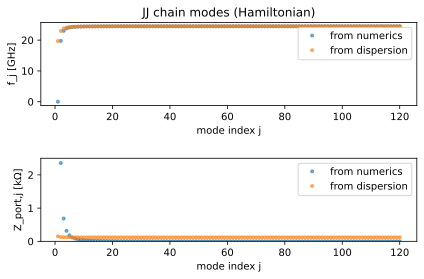

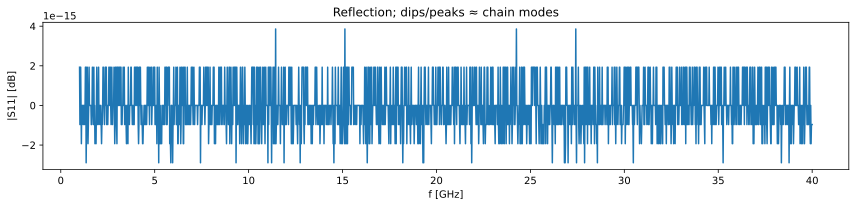

In [19]:


'''
node 0  node 1  node 2           node N
  |       |       |      ...        |
  |      ---     ---               ---
  |      Cg      Cg                Cg      (to ground)
  |       |       |                 |
Cc--+--L--+--L--+--L--+ ... +--L--+--+
       |      |      ...         |
      ---    ---                 ---
       C      C                   C      (series shunt between nodes)

'''


import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

def jjchain_matrices(N, LJ, CJ, Cg):
    """
    N nodes, each node i has:
      - Cg to ground
    Between i and i+1 (for i=0..N-2):
      - LJ inductor
      - CJ capacitor
    Variables: node fluxes φ_i.
    """
    # Capacitance matrix
    C = np.zeros((N, N))

    # Cg to ground
    C += np.eye(N) * Cg

    # Junction capacitances CJ between nodes
    for i in range(N-1):
        C[i, i]     += CJ
        C[i+1, i+1] += CJ
        C[i, i+1]   -= CJ
        C[i+1, i]   -= CJ

    # Inductive Laplacian from LJ between nodes
    K = np.zeros((N, N))
    for i in range(N-1):
        K[i, i]     +=  1.0 / LJ
        K[i+1, i+1] +=  1.0 / LJ
        K[i, i+1]   += -1.0 / LJ
        K[i+1, i]   += -1.0 / LJ

    return C, K


def jjchain_modes(N, LJ, CJ, Cg):
    C, K = jjchain_matrices(N, LJ, CJ, Cg)
    # Solve generalized eigenproblem K v = ω² C v
    w2, V = la.eig(la.solve(C, K))
    w = np.sqrt(np.real(w2))
    idx = np.argsort(w)
    return w[idx], V[:, idx], C

def mode_impedances(C, w, V, port_index=0):
    """
    Compute mode impedances seen at a given port (node index),
    using C_eff^(j) = (v_j^† C v_j) / |v_{port,j}|^2,
    Z_j = 1 / (ω_j C_eff^(j)).
    """
    Nmodes = len(w)
    Z_modes = np.zeros(Nmodes)

    for j in range(Nmodes):
        v = V[:, j]
        # ensure we have real-ish eigenvectors; tiny imag parts can appear numerically
        v = np.real_if_close(v)

        # avoid division by zero if port participation is exactly zero
        v_port = v[port_index]
        if np.abs(v_port) < 1e-18:
            Z_modes[j] = np.inf
            continue

        Ceff = (v.conj().T @ (C @ v)).real / (np.abs(v_port)**2)
        Z_modes[j] = 1.0 / (w[j] * Ceff)

    return Z_modes


def ac_response(N, LJ, CJ, Cg, Cc, R_source=50.0, wvec=None):
    C, K = jjchain_matrices(N, LJ, CJ, Cg)
    if wvec is None:
        wmin, wmax = 2*np.pi*1e9, 2*np.pi*40e9
        wvec = np.linspace(wmin, wmax, 2000)

    S11 = np.zeros_like(wvec, dtype=complex)

    for idx, w in enumerate(wvec):
        Y = 1j*w*C + K/(1j*w)   # full N×N admittance matrix

        # Schur complement to get driving-point admittance at node 0
        Y00 = Y[0, 0]
        Y0r = Y[0, 1:]
        Yr0 = Y[1:, 0]
        Yrr = Y[1:, 1:]
        Ynode = Y00 - Y0r @ la.solve(Yrr, Yr0)

        Znode = 1.0 / Ynode
        Zc = 1.0 / (1j*w*Cc)

        Zin = Zc + Znode
        S11[idx] = (Zin - R_source) / (Zin + R_source)

    return wvec, S11



w, V, C = jjchain_modes(N, LJ, CJ, Cg)
freq_GHz = w / (2*np.pi*GHz)
Z_port = mode_impedances(C, w, V, port_index=0)

print("First 5 eigenfrequencies [GHz]:", freq_GHz[:5])


plt.figure(figsize=(6,4))
plt.subplot(2,1,1)
plt.plot(np.arange(1, N+1), freq_GHz, '.', lw=2, label='from numerics', alpha=0.6)
plt.plot(j, freq_j_GHz, '.', lw=2, label='from dispersion', alpha=0.6)
plt.xlabel('mode index j'); plt.ylabel('f_j [GHz]')
plt.legend()
plt.title('JJ chain modes (Hamiltonian)')

plt.subplot(2,1,2)
plt.plot(np.arange(1, N+1), Z_port/1e3, '.', lw=2, label='from numerics', alpha=0.6)
plt.plot(j, Z_j/1e3, '.', lw=2, label='from dispersion', alpha=0.6)
plt.xlabel('mode index j'); plt.ylabel('Z_port,j [kΩ]')
plt.legend()
plt.tight_layout()
plt.ylim(0, 2.5)
plt.show()



wvec, S11 = ac_response(N, LJ, CJ, Cg, Cc=1e-15)
f = wvec/(2*np.pi*GHz)

plt.figure(figsize=(12,3))
plt.plot(f, 20*np.log10(np.abs(S11)), label="from Hamiltonian")
plt.xlabel('f [GHz]'); plt.ylabel('|S11| [dB]')
plt.title('Reflection; dips/peaks ≈ chain modes')
plt.tight_layout(); plt.show()





### Chain + Cc

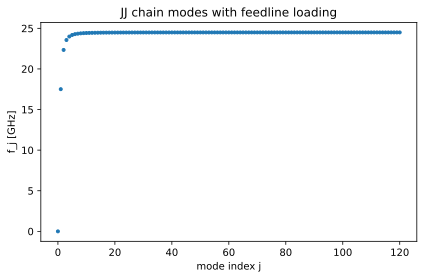

Bare qubit frequency [GHz] = 7.747580267412532


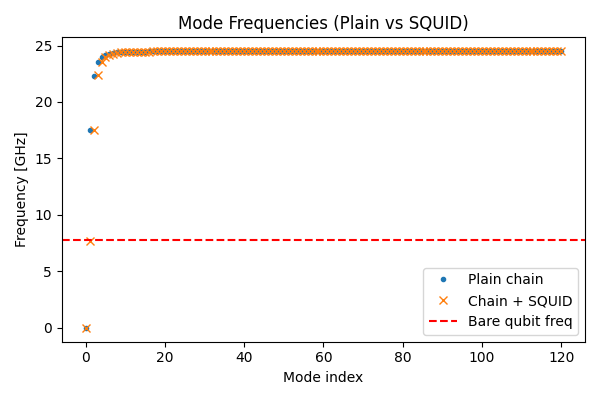

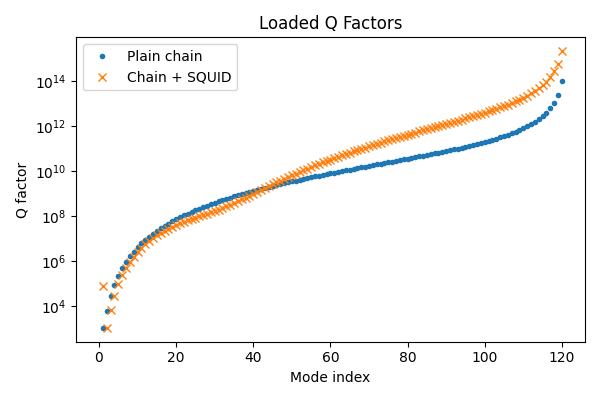

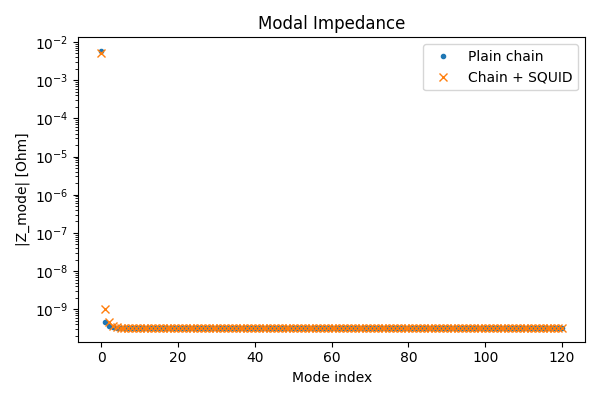

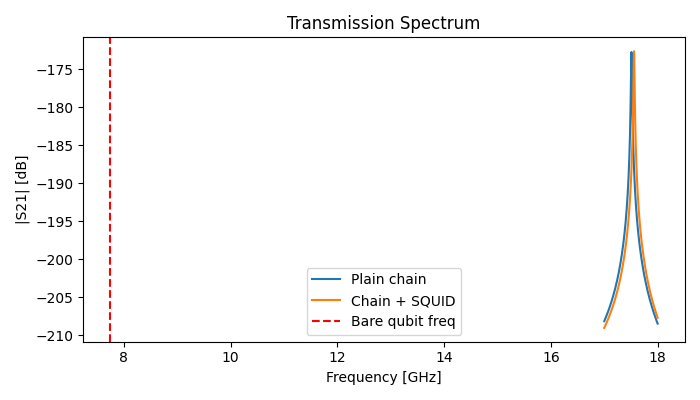

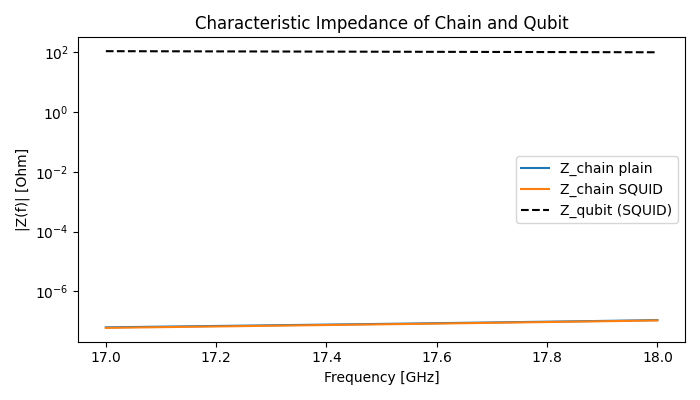

In [ ]:
import numpy as np
from numpy.linalg import inv, eig
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

###############################################################################
# 0. CONSTANTS
###############################################################################

Phi0 = 2.067833848e-15   # flux quantum


###############################################################################
# 1. SQUID EFFECTIVE PARAMETERS
###############################################################################

def squid_EJ_eff(EJ, d, Phi_ext):
    """
    Compute effective EJ of an asymmetric SQUID at external flux Phi_ext.
    EJ = average Josephson energy
    d = asymmetry (0..1)
    """
    EJ1 = EJ*(1+d)
    EJ2 = EJ*(1-d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2*EJ1*EJ2*np.cos(2*np.pi*Phi_ext/Phi0))


def squid_LJ(EJ_eff):
    return Phi0**2/(4*np.pi**2 * EJ_eff)


def squid_CJ(CJ):
    # Capacitance model B → 2CJ
    return 2*CJ


def squid_bare_frequency(EJ, CJ, d, Phi_ext):
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    L = squid_LJ(EJ_eff)
    C = squid_CJ(CJ)
    return 1/(2*np.pi*np.sqrt(L*C))


###############################################################################
# 2. BUILD MATRIX FOR PLAIN CHAIN
###############################################################################

def build_chain_plain(N, LJ, CJ, Cg, Cc, R):
    n_nodes = N + 2
    K = np.zeros((n_nodes, n_nodes))
    C = np.zeros((n_nodes, n_nodes))
    G = np.zeros((n_nodes, n_nodes))

    # JJs
    for j in range(1, N+1):
        i1, i2 = j, j+1
        val = 1/LJ
        K[i1,i1]+=val; K[i2,i2]+=val
        K[i1,i2]-=val; K[i2,i1]-=val

    # JJ capacitances
    for j in range(1, N+1):
        i1, i2 = j, j+1
        C[i1,i1]+=CJ; C[i2,i2]+=CJ
        C[i1,i2]-=CJ; C[i2,i1]-=CJ

    # shunt Cg
    for k in range(2, N+2):
        C[k,k]+=Cg

    # port coupling
    C[0,0]+=Cc; C[1,1]+=Cc
    C[0,1]-=Cc; C[1,0]-=Cc

    # feedline damping
    G[0,0]=1/R
    return K, C, G


###############################################################################
# 3. BUILD MATRIX FOR CHAIN WITH A SQUID BETWEEN N_SQUID and N_SQUID+1
###############################################################################

def build_chain_squid(N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_ext, N_SQUID=None):
    if N_SQUID is None:
        N_SQUID = N - 3

    # SQUID effective params
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    LJ_s = squid_LJ(EJ_eff)
    CJ_s = squid_CJ(CJ)

    n_nodes = N+2
    K = np.zeros((n_nodes, n_nodes))
    C = np.zeros((n_nodes, n_nodes))
    G = np.zeros((n_nodes, n_nodes))

    # Inductors, but SQUID replaces one
    for j in range(1, N+1):
        i1, i2 = j, j+1
        if j == N_SQUID:
            val = 1/LJ_s
        else:
            val = 1/LJ
        K[i1,i1]+=val; K[i2,i2]+=val
        K[i1,i2]-=val; K[i2,i1]-=val

    # JJ capacitances, but SQUID capacitance at its location
    for j in range(1, N+1):
        i1, i2 = j, j+1
        if j == N_SQUID:
            CJ_eff = CJ_s
        else:
            CJ_eff = CJ
        C[i1,i1]+=CJ_eff; C[i2,i2]+=CJ_eff
        C[i1,i2]-=CJ_eff; C[i2,i1]-=CJ_eff

    # shunt Cg
    for k in range(2, N+2):
        C[k,k]+=Cg

    # port coupling
    C[0,0]+=Cc; C[1,1]+=Cc
    C[0,1]-=Cc; C[1,0]-=Cc

    # feed damping
    G[0,0]=1/R

    return K, C, G, N_SQUID, LJ_s, CJ_s


###############################################################################
# 4. UNIVERSAL SOLVERS
###############################################################################

def build_A(K, C, G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A_top = np.hstack([zero, I])
    A_bot = np.hstack([-Cinv@K, -Cinv@G])
    return np.vstack([A_top, A_bot])


def compute_modes(A):
    lam, vec = eig(A)
    mask = np.where(np.imag(lam)>0)[0]
    lam = lam[mask]; vec = vec[:,mask]

    order = np.argsort(np.imag(lam))
    lam = lam[order]; vec = vec[:,order]

    omega = np.imag(lam)
    kappa = -np.real(lam)
    freqs = omega/(2*np.pi)
    Q = omega/(2*kappa)
    return freqs, Q, lam, vec


def compute_mode_impedances(freqs, modes, Cc, R):
    n_modes = len(freqs)
    Z = []
    for j in range(n_modes):
        f = freqs[j]
        w = 2*np.pi*f
        mode = modes[:,j]
        n = len(mode)//2
        phi = mode[:n]
        phi0 = phi[0]
        phi1 = phi[1]
        I = 1j*w*(phi0/R + Cc*(phi0 - phi1))
        Z.append(phi0/I)
    return np.array(Z)


def s21(K,C,G,Cc,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)


###############################################################################
# 5. COMPARISON PLOTS
###############################################################################

def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()


def compare_Q(Q_plain, Q_squid):
    plt.figure(figsize=(6,4))
    plt.plot(Q_plain, '.', label='Plain chain')
    plt.plot(Q_squid, 'x', label='Chain + SQUID')
    plt.yscale('log')
    plt.xlabel("Mode index")
    plt.ylabel("Q factor")
    plt.legend()
    plt.title("Loaded Q Factors")
    plt.tight_layout()
    plt.show()


def compare_Z(Z_plain, Z_squid):
    plt.figure(figsize=(6,4))
    plt.semilogy(np.abs(Z_plain), '.', label='Plain chain')
    plt.semilogy(np.abs(Z_squid), 'x', label='Chain + SQUID')
    plt.xlabel("Mode index")
    plt.ylabel("|Z_mode| [Ohm]")
    plt.legend()
    plt.title("Modal Impedance")
    plt.tight_layout()
    plt.show()


def compare_S21(fspan, S_plain, S_squid, f_q):
    plt.figure(figsize=(7,4))
    plt.plot(fspan/1e9, 20*np.log10(np.abs(S_plain)), label='Plain chain')
    plt.plot(fspan/1e9, 20*np.log10(np.abs(S_squid)), label='Chain + SQUID')
    plt.axvline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("|S21| [dB]")
    plt.legend()
    plt.title("Transmission Spectrum")
    plt.tight_layout()
    plt.show()


###############################################################################
# 9. CHARACTERISTIC IMPEDANCE FUNCTIONS
###############################################################################

def Z_chain_frequency(K, C, G, fspan, node_in=1):
    """
    Compute the input impedance looking into the chain at node `node_in`.
    Feedline is removed (use K,C,G from the full system but zero out shunt R).

    Z_chain(f) = V(node_in)/I(node_in)
    where we inject 1A current into node_in and compute voltage response.
    """
    # Remove feedline loss: zero out G[0,0]
    G2 = G.copy()
    G2[0,0] = 0.0

    Z = []
    n = C.shape[0]

    # Drive vector: current injection at node_in
    b = np.zeros(n)
    b[node_in] = 1.0

    for f in fspan:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G2
        phi = np.linalg.solve(M, b)
        Z.append(phi[node_in])   # since current = 1A
    return np.array(Z)


def Z_qubit_frequency(EJ, CJ, d, Phi_ext, fspan):
    """
    Linearized qubit/squid impedance:
        Z(q) = i*w*L / (1 - w^2 L C)
    where:
        L = LJ(EJ_eff)
        C = 2 CJ (cap model B)
    """
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    L = squid_LJ(EJ_eff)
    C = squid_CJ(CJ)

    Zq = []
    for f in fspan:
        w = 2*np.pi*f
        denom = (1 - w*w*L*C)
        Z = 1j*w*L / denom
        Zq.append(Z)
    return np.array(Zq)

def plot_Z_chain_and_qubit(fspan, Z_chain_plain, Z_chain_squid, Zq):
    plt.figure(figsize=(7,4))
    plt.semilogy(fspan/1e9, np.abs(Z_chain_plain), label='Z_chain plain')
    plt.semilogy(fspan/1e9, np.abs(Z_chain_squid), label='Z_chain SQUID')
    plt.semilogy(fspan/1e9, np.abs(Zq), 'k--', label='Z_qubit (SQUID)')
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("|Z(f)| [Ohm]")
    plt.legend()
    plt.title("Characteristic Impedance of Chain and Qubit")
    plt.tight_layout()
    plt.show()

###############################################################################
# 6. MAIN (example usage)
###############################################################################


# System parameters
N  = 120
LJ = 7.814736424818193e-10
CJ = 5.4000000000000003e-14
Cg = 20e-18
Cc = 1e-15
R  = 50.0

EJ = Phi0**2/(4*np.pi**2 * LJ)   # Convert LJ → EJ
d = 0.1
Phi_ext = 0.5*Phi0
N_SQUID = N//2 #N-3

# Bare SQUID/transmon frequency
f_q = squid_bare_frequency(EJ, CJ, d, Phi_ext)
print("Bare qubit frequency [GHz] =", f_q/1e9)

# Plain chain
Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Ap = build_A(Kp, Cp, Gp)
freqs_plain, Q_plain, lam_p, modes_plain = compute_modes(Ap)
Z_plain = compute_mode_impedances(freqs_plain, modes_plain, Cc, R)

# Chain with SQUID
Ks, Cs, Gs, N_SQUID, LJ_s, CJ_s = build_chain_squid(
    N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_ext, N_SQUID)
As = build_A(Ks, Cs, Gs)
freqs_squid, Q_squid, lam_s, modes_squid = compute_modes(As)
Z_squid = compute_mode_impedances(freqs_squid, modes_squid, Cc, R)

# Frequency sweeps
fspan = np.linspace(1e9, 25e9, 2000)#np.linspace(1e9, 25e9, 2000)
S_plain = s21(Kp, Cp, Gp, Cc, R, fspan)
S_squid = s21(Ks, Cs, Gs, Cc, R, fspan)

# Plots
compare_modes(freqs_plain, freqs_squid, f_q)
compare_Q(Q_plain, Q_squid)
compare_Z(Z_plain, Z_squid)
compare_S21(fspan, S_plain, S_squid, f_q)

# Compute characteristic impedances
Z_chain_plain = Z_chain_frequency(Kp, Cp, Gp, fspan)
Z_chain_squid = Z_chain_frequency(Ks, Cs, Gs, fspan)
Z_q = Z_qubit_frequency(EJ, CJ, d, Phi_ext, fspan)

plot_Z_chain_and_qubit(fspan, Z_chain_plain, Z_chain_squid, Z_q)



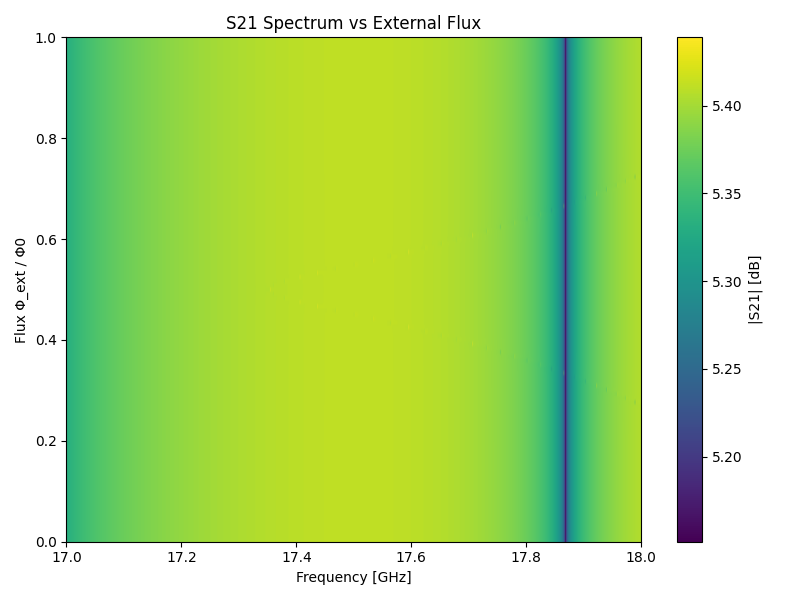

In [ ]:
from tqdm import tqdm

###############################################################################
# S21 vs Flux Spectrum
###############################################################################
# This cell assumes that:
#   - build_chain_squid(...)
#   - s21(...)
#   - parameters EJ, CJ, d, N, LJ, Cg, Cc, R
#   - fspan already defined
# exist in the namespace above.

# # Sweep parameters
# Phi_values = np.linspace(0, 1.0*Phi0, 121)   # 0 → 1 Φ0, 121 steps
# S21_flux_map = np.zeros((len(Phi_values), len(fspan)), dtype=complex)

# for i, Phi_ext in enumerate(tqdm(Phi_values)):
#     # build matrices for each flux
#     Ks, Cs, Gs, N_SQ, LJ_s, CJ_s = build_chain_squid(
#         N, LJ, CJ, Cg, Cc, R,
#         EJ=EJ, d=d, Phi_ext=Phi_ext,
#         N_SQUID=N_SQUID
#     )
#     # compute S21
#     S21_flux_map[i, :] = s21(Ks, Cs, Gs, Cc, R, fspan)


###############################################################################
# Plot as colormap: |S21| vs f vs Flux
###############################################################################
plt.figure(figsize=(8,6))
extent = [fspan[0]/1e9, fspan[-1]/1e9, Phi_values[0]/Phi0, Phi_values[-1]/Phi0]

# plt.imshow(
#     20*np.log10(np.abs(S21_flux_map)),
#     aspect='auto',
#     origin='lower',
#     extent=extent,
#     cmap='viridis'
# )

plt.imshow(
    np.log(-20*np.log10(np.abs(S21_flux_map))),
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='viridis'
)

plt.colorbar(label='|S21| [dB]')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Φ_ext / Φ0')
plt.title('S21 Spectrum vs External Flux')
plt.tight_layout()
plt.show()


Qubit freq [GHz]: 6.0155
lowest few [GHz]: [2.12492961e-06 6.01440777e+00 1.39761028e+01 1.98087428e+01
 2.19113913e+01 2.27930607e+01]


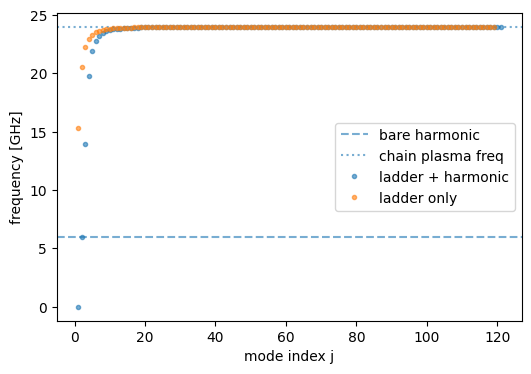

In [ ]:
'''
Replace a sinple osc by a harm mode


[ Qubit place-holder = single LC ]


'''

def ladder_plus_harmonic(N, LJ, CJ, Cg, Lq, Cq, Ck):
    # JJ chain (N nodes)
    C, K = jjchain_matrices(N, LJ, CJ, Cg)

    # Add qubit node N (index N), shunted by Cq and Lq to ground
    C_aug = np.zeros((N+1, N+1))
    K_aug = np.zeros((N+1, N+1))
    C_aug[:N, :N] = C
    K_aug[:N, :N] = K

    C_aug[N, N] += Cq
    K_aug[N, N] += 1.0 / Lq

    # Coupling capacitor Ck between node 0 and qubit node N
    C_aug[0, 0] += Ck
    C_aug[N, N] += Ck
    C_aug[0, N] -= Ck
    C_aug[N, 0] -= Ck

    w2, V = la.eig(la.solve(C_aug, K_aug))
    w = np.sqrt(np.real(w2))
    idx = np.argsort(w)
    return w[idx], V[:, idx]


Lq, Cq = 0.7e-9, 1e-12      # taken from earlier qubit design
wq = 1/np.sqrt(Lq*Cq)
fq_GHz = wq/(2*np.pi*GHz)


Ck = 0.4e-15 # TODO it might be 2nd order

w, V = ladder_plus_harmonic(N=N, LJ=LJ, CJ=CJ, Cg=Cg,
                            Lq=Lq, Cq=Cq, Ck=Ck)

f = w/(2*np.pi*GHz)
print("Qubit freq [GHz]: {:.4f}".format(fq_GHz))
print("lowest few [GHz]:", f[:6])

plt.figure(figsize=(6,4))
plt.axhline(fq_GHz, ls='--', alpha=0.6, label='bare harmonic')
plt.axhline(wp_target/(2*np.pi*GHz), ls=':', alpha=0.6, label='chain plasma freq')
plt.plot(np.arange(1, N+2), f, '.', lw=2, label='ladder + harmonic', alpha=0.6)
plt.plot(np.arange(1, N+1), freq_GHz, '.', lw=2, label='ladder only', alpha=0.6)
plt.xlabel('mode index j'); plt.ylabel('frequency [GHz]')
plt.legend()
plt.show()



### Including Qubit

=== Step 1: JJ junction & chain design ===
JJ parameters (from plasma target 25.0 GHz):
  CJ = 10.00 fF, Cg = 1.00 fF
  LJ = 4.05 nH
  EJ_chain/h = 40.33 GHz, EC_chain/h = 0.969 GHz
  Plasma frequency wp/2π = 25.000 GHz

Chain: first few mode freqs [GHz]: [2.04566022 4.05050639 5.97767338 7.7973391  9.48842509]
Chain: last few mode freqs  [GHz]: [24.6919677  24.6924265  24.69278272 24.69303683 24.69318916]



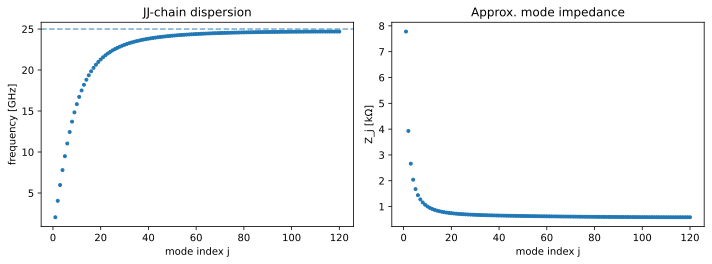

=== Step 2: Transmon (t-mon) design ===
Transmon parameters:
  EJq/h = 15.00 GHz, EC/h = 0.250 GHz
  CSigma = 77.48 fF, LJq = 10.90 nH
  ZT = 375.0 Ω
  f01 ≈ 5.227 GHz



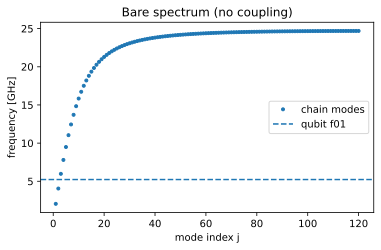

=== Step 3: Couplings g_j and anticrossings ===
For η = 0.01:
  Lowest mode gap 2g_low ≈ 9.0 MHz
  Highest mode gap 2g_top ≈ 395.1 MHz
  Condition check: 2g_top/2π ≪ wp/2π=25.0 GHz ? (here 2g_top/2π ≈ 0.395 GHz)



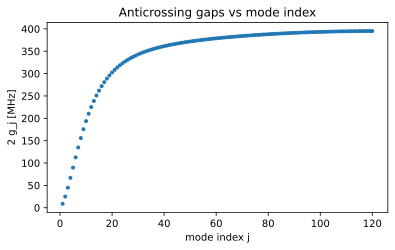

=== Step 4: Dispersive shift χ and Purcell Q for a readout mode ===
Chosen readout target ≈ 20.0 GHz
  Closest mode index j* = 16, f_j*/2π ≈ 19.840 GHz
  Detuning Δ/2π = (ω_j* - ω_q)/2π ≈ 14.612 GHz
  g_j*/2π = 135.9 MHz
  Dispersive shift χ/2π ≈ 1264.6 kHz
  Purcell Q ≈ 1.52e+07



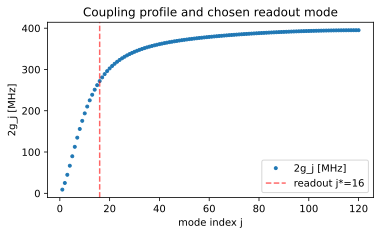


=== Design run complete ===


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as const

# Optional: comment out if you don't have scqubits installed yet
import scqubits as scq


# ============================================================
# 0. Constants
# ============================================================

h = const.h
hbar = const.hbar
e = const.e
Phi0 = h / (2 * e)
GHz = 1e9
fF_to_F = 1e-15


# ============================================================
# 1. JJ chain design & dispersion
# ============================================================

def design_junction(fp_target_GHz=25.0,
                    W_um=0.2,
                    L_um=2.0,
                    C_area_fF_per_um2=50.0,
                    Cg_over_CJ=0.1):
    """
    Design a single JJ from target plasma frequency and geometry.
    Returns: CJ, Cg, LJ, EJ_GHz, EC_GHz, wp_target
    """
    wp_target = 2 * np.pi * fp_target_GHz * GHz  # rad/s

    area_um2 = W_um * L_um
    CJ = C_area_fF_per_um2 * area_um2 * fF_to_F  # [F]
    LJ = 1.0 / (wp_target ** 2 * CJ)             # [H]

    # linearized energies of this junction if used as a "qubit" element
    EJ = (Phi0 / (2 * np.pi))**2 / LJ           # [J]
    EJ_GHz = EJ / h / GHz

    EC = e**2 / (2 * (2 * CJ))                  # note factor 2*CJ (island sees two caps)
    EC_GHz = EC / h / GHz

    Cg = Cg_over_CJ * CJ

    return CJ, Cg, LJ, EJ_GHz, EC_GHz, wp_target


def jjchain_dispersion(N, wp_target, LJ, CJ, Cg, a):
    """
    Analytic JJ-chain dispersion for open-open boundary conditions.
    Returns: mode index j, k, omega_j [rad/s], freq_j_GHz, effective Ceff_k, Z_j.
    """
    import numpy as np
    
    j = np.arange(1, N + 1)
    # k is the wave number (a is the unit cell length)
    k = np.pi * j / ((N + 1) * a) 

    # 1. Dispersion Relation (omega_j)
    s = np.sin(0.5 * k * a)
    omega_j = wp_target * (np.abs(s) / np.sqrt(s**2 + Cg / (4 * CJ)))
    freq_j_GHz = omega_j / (2 * np.pi * GHz)

    # 2. Effective Capacitance
    # Ceff_k is the k-dependent effective shunt capacitance of the chain
    Ceff_k = Cg * (1 - np.cos(k * a)) / 2.0
    
    Z_j = 1 / (omega_j * (CJ + Ceff_k))    # [Ohm]
    
    
    return j, k, omega_j, freq_j_GHz, Ceff_k, Z_j


# ============================================================
# 2. Transmon design (self-shunted t-mon)
# ============================================================

def design_transmon(EJq_GHz, EC_GHz):
    """
    From EJ/h and EC/h in GHz, compute CSigma, LJq, ZT, f01.
    Returns: CSigma, LJq, ZT, wq [rad/s], f01_GHz
    """
    EJq = EJq_GHz * h * GHz
    EC = EC_GHz * h * GHz

    CSigma = e**2 / (2 * EC)                     # [F]
    LJq = (Phi0 / (2 * np.pi))**2 / EJq          # [H]
    ZT = np.sqrt(LJq / CSigma)                   # [Ohm]

    # transmon frequency (approx)
    wq = np.sqrt(8 * EJq * EC) / hbar - EC / hbar
    f01_GHz = wq / (2 * np.pi * GHz)

    return CSigma, LJq, ZT, wq, f01_GHz


# ============================================================
# 3. Couplings g_j from impedance ratio
# ============================================================

def compute_couplings(omega_j, Z_j, ZT, eta=0.2):
    """
    Compute g_j (rad/s) and anticrossing gaps 2g_j (MHz) from
    heuristic scaling g_j / ω_j ~ η sqrt(ZT/Z_j).
    Returns: g_j [rad/s], gap_MHz.
    """

    # avoid division by zero
    Z_j_safe = np.maximum(Z_j, 1e-9)

    g_j = eta * omega_j * np.sqrt(np.maximum(ZT, 1e-9) / Z_j_safe)
    gap_MHz = (2 * g_j) / (2 * np.pi * 1e6)

    return g_j, gap_MHz


def plot_coupling_gaps(j, gap_MHz, etas=None,
                       omega_j_list=None, Z_j_list=None, ZT=None):
    """
    Either plot a single gap_MHz vs j,
    or sweep over etas if omega_j_list & Z_j_list & ZT given.
    """
    plt.figure(figsize=(5.6, 3.6))

    if etas is None:
        plt.plot(j, gap_MHz, '.', lw=2)
    else:
        for eta in etas:
            g_j, gap = compute_couplings(omega_j_list, Z_j_list, ZT, eta)
            plt.plot(j, gap, '.',  lw=2, label=f"η={eta}")

        plt.legend()

    plt.xlabel("mode index j")
    plt.ylabel("2 g_j [MHz]")
    plt.title("Anticrossing gaps vs mode index")
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Dispersive shift χ and Purcell Q for a chosen mode
# ============================================================

def choose_readout_mode(freq_j_GHz, target_GHz):
    """
    Choose the chain mode index closest to target_GHz.
    Returns: j_star index, f_mode_GHz.
    """
    j_arr = np.arange(1, len(freq_j_GHz) + 1)
    j_star = np.argmin(np.abs(freq_j_GHz - target_GHz))
    f_mode_GHz = freq_j_GHz[j_star]
    return j_star, f_mode_GHz, j_arr


def dispersive_and_purcell(omega_j, g_j, wq,
                           j_star, Qr_target):
    """
    Compute χ, Purcell Q for a chosen mode j_star.
    Returns: chi [rad/s], chi_kHz, Q_Purcell, Delta [rad/s].
    """
    wj_star = omega_j[j_star]
    gj_star = g_j[j_star]

    Delta = wj_star - wq

    chi = gj_star**2 / np.maximum(np.abs(Delta), 1e-16)   # [rad/s]
    chi_kHz = chi / (2 * np.pi * 1e3)

    kappa = wj_star / Qr_target
    Gamma_P = kappa * (gj_star / np.maximum(np.abs(Delta), 1e-16))**2
    Q_Purcell = wq / np.maximum(Gamma_P, 1e-30)

    return chi, chi_kHz, Q_Purcell, Delta


# ============================================================
# 5. scqubits multimode model (optional)
# ============================================================

import numpy as np
import scqubits as scq
import qutip as qt  # make sure qutip is installed: pip install qutip


import numpy as np
import scqubits as scq
import qutip as qt  # pip install qutip


import numpy as np
import scqubits as scq
import qutip as qt  # pip install qutip


def build_scqubits_model(
    EJq_GHz,
    EC_GHz,
    modes_GHz,
    g_list_GHz,
    ncut=60,
    dim_tr=6,   # still useful for analysis & plotting, but not for Hilbert-space size
    dim_ho=8,
    flux=0.0,
    d=0.01,
    use_charge_coupling=True,
):
    """
    Transmon (scqubits) + multiple harmonic modes (QuTiP oscillators).

    Hilbert space: [HO_0 ⊗ HO_1 ⊗ ... ⊗ HO_{M-1} ⊗ Transmon(full ncut-space)]

    - modes_GHz: list of mode frequencies (GHz)
    - g_list_GHz: same length, couplings g_i in GHz
    """

    # 1) Transmon
    tr = scq.TunableTransmon(
        EJmax=EJq_GHz,
        EC=EC_GHz,
        ng=0.0,
        d=d,
        ncut=ncut,
        truncated_dim=dim_tr,
        flux=flux,
    )

    # Get the full transmon Hamiltonian and its actual dimension
    H_tr = tr.hamiltonian()            # numpy array, shape (dim_tr_full, dim_tr_full)
    dim_tr_full = H_tr.shape[0]

    n_modes = len(modes_GHz)
    # Use *full* transmon dimension here, not truncated_dim
    dims = [dim_ho] * n_modes + [dim_tr_full]
    tr_index = n_modes  # transmon is last subsystem

    # 2) Helper to embed local operator into full space
    def embed_local_op(op, which):
        """
        Take an operator op (numpy array or Qobj) acting on subsystem 'which'
        and embed it into the full tensor-product Hilbert space.
        """
        # ensure op is a Qobj with correct local dimension
        if not isinstance(op, qt.Qobj):
            op = qt.Qobj(op)

        ops = []
        for k, d_k in enumerate(dims):
            if k == which:
                ops.append(op)
            else:
                ops.append(qt.qeye(d_k))
        return qt.tensor(ops)

    # 3) Build free Hamiltonian H_0 = Σ_i H_ho_i + H_tr
    # Start with a zero operator in the full space
    # (use identity on the first subsystem just to get a Qobj of right dims)
    H = 0 * embed_local_op(qt.qeye(dims[0]), which=0)

    # Oscillators: use QuTiP destroy and H = f_mode * a† a  (GHz)
    a_locals = []
    for i, f_mode in enumerate(modes_GHz):
        a = qt.destroy(dim_ho)         # local HO annihilation
        a_locals.append(a)
        H_ho_i = f_mode * (a.dag() * a)  # local HO Hamiltonian in GHz
        H += embed_local_op(H_ho_i, which=i)

    # Add transmon free Hamiltonian (now dims match: dim_tr_full)
    H += embed_local_op(H_tr, which=tr_index)

    # 4) Couplings
    if use_charge_coupling:
        # n_operator is in the full charge basis (dim_tr_full x dim_tr_full)
        n_op_tr = tr.n_operator()
        n_op_full = embed_local_op(n_op_tr, which=tr_index)

        for i, g in enumerate(g_list_GHz):
            a = a_locals[i]
            a_plus_adag_full = embed_local_op(a + a.dag(), which=i)
            # H_int_i = - g * (a_i + a_i†) ⊗ n̂_q  (GHz)
            H += -g * (a_plus_adag_full * n_op_full)
    else:
        raise NotImplementedError("Use charge coupling for now (use_charge_coupling=True).")

    # 5) Diagonalize
    evals = H.eigenenergies()     # in GHz
    evals_sorted = np.sort(np.real(evals))

    return tr, H, evals_sorted






# ============================================================
# 6. Top-level runner tying everything together
# ============================================================

def run_full_design(
    # JJ chain targets
    fp_target_GHz=25.0,
    W_um=0.2,
    L_um=2.0,
    C_area_fF_per_um2=50.0,
    Cg_over_CJ=0.1,
    N=120,
    a_um=0.2,           # lattice spacing (approx pitch)
    # Transmon targets
    EJq_GHz=56.9,
    ECq_GHz=0.48,
    # Coupling scaling
    eta=0.2,
    # Readout & Purcell
    readout_target_GHz=20.0,
    Qr_target=5e3,
    # scqubits options
    use_scqubits=True,
    n_modes_scq=3
):
    print("=== Step 1: JJ junction & chain design ===")
    CJ, Cg, LJ, EJ_chain_GHz, EC_chain_GHz, wp_target = design_junction(
        fp_target_GHz, W_um, L_um, C_area_fF_per_um2, Cg_over_CJ
    )

    print(f"JJ parameters (from plasma target {fp_target_GHz:.1f} GHz):")
    print(f"  CJ = {CJ*1e15:.2f} fF, Cg = {Cg*1e15:.2f} fF")
    print(f"  LJ = {LJ*1e9:.2f} nH")
    print(f"  EJ_chain/h = {EJ_chain_GHz:.2f} GHz, EC_chain/h = {EC_chain_GHz:.3f} GHz")
    print(f"  Plasma frequency wp/2π = {wp_target/(2*np.pi*GHz):.3f} GHz")
    print()

    a = a_um * 1e-6

    j, k, omega_j, freq_j_GHz, Ceff_k, Z_j = jjchain_dispersion(
        N, wp_target, LJ, CJ, Cg, a
    )

    print("Chain: first few mode freqs [GHz]:", freq_j_GHz[:5])
    print("Chain: last few mode freqs  [GHz]:", freq_j_GHz[-5:])
    print()

    # Plot dispersion & impedances
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    ax[0].plot(j, freq_j_GHz, ".", lw=2)
    ax[0].axhline(fp_target_GHz, ls="--", alpha=0.6)
    ax[0].set_xlabel("mode index j")
    ax[0].set_ylabel("frequency [GHz]")
    ax[0].set_title("JJ-chain dispersion")

    ax[1].plot(j, Z_j/1e3, ".", lw=2)
    ax[1].set_xlabel("mode index j")
    ax[1].set_ylabel("Z_j [kΩ]")
    ax[1].set_title("Approx. mode impedance")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    print("=== Step 2: Transmon (t-mon) design ===")
    CSigma, LJq, ZT, wq, f01_GHz = design_transmon(EJq_GHz, ECq_GHz)

    print(f"Transmon parameters:")
    print(f"  EJq/h = {EJq_GHz:.2f} GHz, EC/h = {ECq_GHz:.3f} GHz")
    print(f"  CSigma = {CSigma*1e15:.2f} fF, LJq = {LJq*1e9:.2f} nH")
    print(f"  ZT = {ZT:.1f} Ω")
    print(f"  f01 ≈ {f01_GHz:.3f} GHz")
    print()

    # Plot bare spectrum
    plt.figure(figsize=(5.4, 3.6))
    plt.plot(j, freq_j_GHz,'.',  label="chain modes")
    plt.axhline(f01_GHz, ls="--", label="qubit f01")
    plt.xlabel("mode index j")
    plt.ylabel("frequency [GHz]")
    plt.title("Bare spectrum (no coupling)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    print("=== Step 3: Couplings g_j and anticrossings ===")
    g_j, gap_MHz = compute_couplings(omega_j, Z_j, ZT, eta=eta)

    gap_top_MHz = gap_MHz[-1]
    gap_low_MHz = gap_MHz[0]
    print(f"For η = {eta:.2f}:")
    print(f"  Lowest mode gap 2g_low ≈ {gap_low_MHz:.1f} MHz")
    print(f"  Highest mode gap 2g_top ≈ {gap_top_MHz:.1f} MHz")
    print(f"  Condition check: 2g_top/2π ≪ wp/2π={fp_target_GHz:.1f} GHz ? "
          f"(here 2g_top/2π ≈ {gap_top_MHz/1e3:.3f} GHz)")
    print()

    plot_coupling_gaps(j, gap_MHz)

    # # Optionally, sweep eta
    # etas_sweep = [0.01, 0.1, 0.3, 0.5]
    # plot_coupling_gaps(j, None, etas=etas_sweep,
    #                    omega_j_list=omega_j, Z_j_list=Z_j, ZT=ZT)

    # --------------------------------------------------------
    print("=== Step 4: Dispersive shift χ and Purcell Q for a readout mode ===")
    j_star, f_mode_GHz, j_arr = choose_readout_mode(freq_j_GHz, readout_target_GHz)
    chi, chi_kHz, Q_Purcell, Delta = dispersive_and_purcell(
        omega_j, g_j, wq, j_star, Qr_target
    )

    print(f"Chosen readout target ≈ {readout_target_GHz:.1f} GHz")
    print(f"  Closest mode index j* = {j_star+1}, f_j*/2π ≈ {f_mode_GHz:.3f} GHz")
    print(f"  Detuning Δ/2π = (ω_j* - ω_q)/2π ≈ {(Delta/(2*np.pi*GHz)):.3f} GHz")
    print(f"  g_j*/2π = {g_j[j_star]/(2*np.pi*1e6):.1f} MHz")
    print(f"  Dispersive shift χ/2π ≈ {chi_kHz:.1f} kHz")
    print(f"  Purcell Q ≈ {Q_Purcell:.2e}")
    print()

    # quick plot of g_j and χ for this mode
    plt.figure(figsize=(5.4, 3.4))
    plt.plot(j, gap_MHz, '.', label="2g_j [MHz]")
    plt.axvline(j_star+1, color="r", ls="--", alpha=0.6,
                label=f"readout j*={j_star+1}")
    plt.xlabel("mode index j")
    plt.ylabel("2g_j [MHz]")
    plt.title("Coupling profile and chosen readout mode")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =======================================================
    # 5. scqubits multi-mode model (optional)
    # =======================================================
    if use_scqubits:
        print("=== Step 5: scqubits multimode model (Transmon + few chain modes) ===")

        # convert classical g_j (rad/s) to GHz for selected modes
        # choose n_modes_scq nearest to readout_target_GHz
        idx_sorted = np.argsort(np.abs(freq_j_GHz - readout_target_GHz))
        idx_modes = idx_sorted[:n_modes_scq]
        idx_modes = np.sort(idx_modes)

        modes_GHz = freq_j_GHz[idx_modes]
        g_list_GHz = g_j[idx_modes] / (2 * np.pi * GHz)

        print("Modes included in scqubits model:")
        for idx_m, f_m, g_m in zip(idx_modes, modes_GHz, g_list_GHz):
            print(f"  j={idx_m+1:3d}, f_j/2π={f_m:6.3f} GHz, g_j/2π={g_m*1e3:6.1f} MHz")

        tr, H, evals_sorted = build_scqubits_model(
            EJq_GHz=EJq_GHz,
            EC_GHz=ECq_GHz,
            modes_GHz=modes_GHz,
            g_list_GHz=g_list_GHz,
            ncut=60,
            dim_tr=6,
            dim_ho=8,
            flux=0.0,
            d=0.01,
            use_charge_coupling=True,
        )

        print("\nLowest 10 eigenlevels of full model [GHz]:")
        for n, E in enumerate(evals_sorted[:10]):
            print(f"  E_{n} ≈ {E:.4f} GHz")

        # approximate qubit 0-1 splitting from bare transmon
        f01_bare = tr.levels_eigvals(evals_count=2)[1] - tr.levels_eigvals(evals_count=2)[0]
        print(f"\nBare transmon f01 from scqubits: {f01_bare:.4f} GHz (approx)")

    print("\n=== Design run complete ===")


# ============================================================
# Example call (you can edit parameters here or call from notebook)
# ============================================================

if __name__ == "__main__":
    run_full_design(
        fp_target_GHz=25.0,
        W_um=0.1,
        L_um=2.0,
        C_area_fF_per_um2=50.0,
        Cg_over_CJ=0.10,
        N=120,
        a_um=0.2,
        EJq_GHz=15,
        ECq_GHz=0.25,
        eta=0.01,
        readout_target_GHz=20.0,
        Qr_target=5e3,
        use_scqubits=False,   # set True when you want the quantum model
        n_modes_scq=3
    )


### Introduce Kerr non-lin instead of harm osc